# QCBM on IBM Hardware for Molecular Data Augmentation

## Overview

This project implements a **Quantum Circuit Born Machine (QCBM)** to perform **molecular data augmentation** using real IBM Quantum hardware.

The goal is to learn the **probability distribution of molecules** in a chemically meaningful latent space and generate **new, synthesizable molecules**.

Quantum model: QCBM

Hardware: IBM Quantum ibm_fez

Qubits used: 5

States represented: 32

Molecular encoding: SMILES → SELFIES → token-count vectors

State discretization: KMeans clustering

Entanglement strategy: Chow–Liu-inspired / hardware-aware sparse CZ topology

Hardware gates used: rz, sx, cz, measure

Evaluation: KL, TV, Fidelity, MMD, Sinkhorn, SYBA, validity, uniqueness

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

TOKEN = "<your-ibm-cloud-api-token>"

INSTANCE = "<your-ibm-cloud-instance-id>"

QiskitRuntimeService.save_account(
    channel="ibm_cloud",
    token=TOKEN.strip(),
    instance=INSTANCE.strip(),
    name="default-ibm-cloud",
    overwrite=True,
    set_as_default=True
)

service = QiskitRuntimeService(name="default-ibm-cloud")

print(service.backends())

[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_kingston')>, <IBMBackend('ibm_marrakesh')>]


In [20]:
# ============================================================
# CELL 1 — Imports
# ============================================================

import os
import time
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import selfies as sf
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from rdkit.DataStructs.cDataStructs import TanimotoSimilarity

from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

from scipy.optimize import minimize
from scipy.spatial.distance import jensenshannon

from syba.syba import SybaClassifier

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeBelemV2

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [21]:
# ============================================================
# CELL 2 — Configuration
# ============================================================

DATA_PATH = "DATA/KRAS_G12D_inhibitors_update202209_updated.csv"

N_BINS = 32
N_QUBITS = int(np.log2(N_BINS))
SHOTS = 2000
N_QUANTUM_SAMPLES = 300
N_CLASSICAL_MUTATIONS_PER_MOLECULE = 1

MAX_SELFIES_TOKENS = 32
QCBM_LAYERS = 3
OPT_MAXITER = 250

BACKEND_NAME = "ibm_fez"

print("Bins:", N_BINS)
print("Qubits:", N_QUBITS)

Bins: 32
Qubits: 5


In [22]:
# ============================================================
# CELL 3 — Load KRAS Dataset and SELFIES
# ============================================================

df = pd.read_csv(DATA_PATH)

def safe_selfies(smiles):
    try:
        return sf.encoder(smiles)
    except Exception:
        return None

df = df[["id", "smiles"]].copy()
df["selfies"] = df["smiles"].apply(safe_selfies)
df = df.dropna(subset=["selfies"]).reset_index(drop=True)

print("Valid SELFIES molecules:", len(df))
df.head()

Valid SELFIES molecules: 636


,id,smiles,selfies
0,1,CN1[C@H](COc2nc3cc(-c4cc(O)cc5ccccc45)ncc3c(N3...,[C][N][C@H1][Branch2][Branch1][=Branch1][C][O]...
1,2,CN1[C@H](COc2nc(N3CC(CC4)NC4C3)c(cnc(-c3cc(O)c...,[C][N][C@H1][Branch2][Branch1][#Branch2][C][O]...
2,3,Cn1c(CCOc2nc(N3CC(CC4)NC4C3)c(cnc(-c3cc(O)cc4c...,[C][N][C][Branch2][Branch1][O][C][C][O][C][=N]...
3,4,Oc1cc2ccccc2c(-c(ncc(c2n3)c(N4CC(CC5)NC5C4)nc3...,[O][C][=C][C][=C][C][=C][C][=C][Ring1][=Branch...
4,5,Cn1nccc1COc1nc(N2CC(CC3)NC3C2)c(cnc(-c2cc(O)cc...,[C][N][N][=C][C][=C][Ring1][Branch1][C][O][C][...


In [23]:
# ============================================================
# CELL 4 — SYBA Setup
# ============================================================

syba = SybaClassifier()
syba.fitDefaultScore()

def syba_score_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        Chem.SanitizeMol(mol)
        return syba.predict(mol=mol)
    except Exception:
        return np.nan

def valid_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        Chem.SanitizeMol(mol)
        return True
    except Exception:
        return False

In [24]:
# ============================================================
# CELL 5 — SELFIES Latent Space
# ============================================================

def selfies_to_latent(selfies_list, max_tokens=32):
    vocab_counter = Counter()
    for s in selfies_list:
        vocab_counter.update(sf.split_selfies(s))

    vocab = [tok for tok, _ in vocab_counter.most_common(max_tokens)]
    token_to_idx = {tok: i for i, tok in enumerate(vocab)}

    X = np.zeros((len(selfies_list), len(vocab)))

    for i, s in enumerate(selfies_list):
        counts = Counter(sf.split_selfies(s))
        for tok, count in counts.items():
            if tok in token_to_idx:
                X[i, token_to_idx[tok]] = count

    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    return X, vocab

X_latent, vocab = selfies_to_latent(df["selfies"].tolist(), MAX_SELFIES_TOKENS)

print("Latent shape:", X_latent.shape)
print("Vocab size:", len(vocab))

Latent shape: (636, 32)
Vocab size: 32


In [25]:
# ============================================================
# CELL 6 — KMeans Molecular Bins = Target States
# ============================================================

kmeans = KMeans(n_clusters=N_BINS, random_state=SEED, n_init=20)
df["bin"] = kmeans.fit_predict(X_latent)

bin_counts = df["bin"].value_counts().sort_index()
p_target = np.zeros(N_BINS)

for i in range(N_BINS):
    p_target[i] = bin_counts.get(i, 0)

p_target = p_target / p_target.sum()

print("Target mass:", p_target.sum())
print("Target distribution:", p_target)

Target mass: 1.0
Target distribution: [0.02358491 0.02201258 0.02672956 0.02515723 0.0408805  0.03301887
 0.06289308 0.01886792 0.02358491 0.06289308 0.04402516 0.01886792
 0.06289308 0.01886792 0.02044025 0.01572327 0.04245283 0.02987421
 0.02672956 0.02201258 0.02672956 0.02672956 0.0172956  0.03301887
 0.04874214 0.02830189 0.02830189 0.03144654 0.01886792 0.02358491
 0.02672956 0.04874214]


In [26]:
# ============================================================
# CELL 7 — Distribution Metrics
# ============================================================

def normalize(p):
    p = np.asarray(p, dtype=float)
    p = np.clip(p, 1e-12, None)
    return p / p.sum()

def kl_divergence(p, q):
    p, q = normalize(p), normalize(q)
    return float(np.sum(p * np.log(p / q)))

def total_variation(p, q):
    p, q = normalize(p), normalize(q)
    return float(0.5 * np.sum(np.abs(p - q)))

def fidelity(p, q):
    p, q = normalize(p), normalize(q)
    return float(np.sum(np.sqrt(p * q)) ** 2)

def mmd_rbf(p, q, gammas=(0.1, 1.0, 10.0)):
    p, q = normalize(p), normalize(q)
    x = np.arange(len(p)).reshape(-1, 1)

    K = np.zeros((len(p), len(p)))
    for g in gammas:
        dist2 = (x - x.T) ** 2
        K += np.exp(-g * dist2)

    K /= len(gammas)
    diff = p - q
    return float(diff.T @ K @ diff)

def sinkhorn_1d(p, q):
    try:
        from scipy.stats import wasserstein_distance
        x = np.arange(len(p))
        return float(wasserstein_distance(x, x, normalize(p), normalize(q)))
    except Exception:
        return np.nan

def distribution_report(name, p, target):
    return {
        "method": name,
        "KL(ref||test)": kl_divergence(target, p),
        "TV": total_variation(target, p),
        "Fidelity": fidelity(target, p),
        "MMD": mmd_rbf(target, p),
        "Sinkhorn/Wasserstein": sinkhorn_1d(target, p),
    }

In [27]:
# ============================================================
# CELL 8 — Classical STONED-SELFIES Helpers
# ============================================================

def get_selfie_chars(selfie):
    return list(sf.split_selfies(selfie))

def sanitize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi, sanitize=True)
        smi_canon = Chem.MolToSmiles(mol, isomericSmiles=False, canonical=True)
        return mol, smi_canon, True
    except Exception:
        return None, None, False

def mutate_selfie(selfie, max_molecules_len):
    chars_selfie = get_selfie_chars(selfie)
    alphabet = list(sf.get_semantic_robust_alphabet())

    while True:
        random_choice = np.random.choice([1, 2, 3])

        if random_choice == 1:
            random_index = np.random.randint(len(chars_selfie) + 1)
            random_character = np.random.choice(alphabet)
            mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index:]

        elif random_choice == 2:
            random_index = np.random.randint(len(chars_selfie))
            random_character = np.random.choice(alphabet)
            mutated_chars = chars_selfie[:random_index] + [random_character] + chars_selfie[random_index + 1:]

        else:
            if len(chars_selfie) <= 1:
                continue
            random_index = np.random.randint(len(chars_selfie))
            mutated_chars = chars_selfie[:random_index] + chars_selfie[random_index + 1:]

        mutated_selfie = "".join(mutated_chars)

        try:
            smiles = sf.decoder(mutated_selfie)
            mol, smiles_canon, done = sanitize_smiles(smiles)

            if len(mutated_chars) > max_molecules_len or smiles_canon == "":
                done = False

            if done:
                return mutated_selfie, smiles_canon
        except Exception:
            pass

def depth_n_selfies_mutation(selfies, depth):
    origin_selfies = selfies
    len_origin = len(get_selfie_chars(origin_selfies))
    current = origin_selfies

    for _ in range(depth):
        current, _ = mutate_selfie(current, len_origin + depth)

    return current

def classical_stoned_generate(df, mutations_per_molecule=1, max_depth=5):
    start = time.perf_counter()

    records = []

    for _, row in df.iterrows():
        base_selfies = row["selfies"]

        for _ in range(mutations_per_molecule):
            depth = random.randint(1, max_depth)

            try:
                mutated_selfies = depth_n_selfies_mutation(base_selfies, depth)
                mutated_smiles = sf.decoder(mutated_selfies)

                if valid_smiles(mutated_smiles):
                    score = syba_score_smiles(mutated_smiles)
                    records.append({
                        "smiles": Chem.MolToSmiles(Chem.MolFromSmiles(mutated_smiles)),
                        "selfies": mutated_selfies,
                        "syba_score": score,
                        "method": "Classical_STONED"
                    })
            except Exception:
                pass

    elapsed = time.perf_counter() - start
    return pd.DataFrame(records), elapsed

In [28]:
# ============================================================
# CELL 9 — Run Classical Baseline
# ============================================================

df_classical, classical_time = classical_stoned_generate(
    df,
    mutations_per_molecule=N_CLASSICAL_MUTATIONS_PER_MOLECULE,
    max_depth=5
)

print("Classical generated molecules:", len(df_classical))
print("Classical time:", classical_time)

df_classical.head()

Classical generated molecules: 636
Classical time: 3.4185964999487624


,smiles,selfies,syba_score,method
0,CCC1CNC(C)(c2cnc(-c3cc(O)cc4ccccc34)cc2N=COC[C...,[C][N][C@H1][Branch2][Branch1][=Branch1][C][O]...,-59.113085,Classical_STONED
1,CCC[C@@H](COC=NC(N[S-]1CC2CCC(C1)N2)=C1C=NC(c2...,[C][N][C@H1][Branch2][Branch1][#Branch2][C][O]...,-69.576528,Classical_STONED
2,CCC1CN2C(=CC=NC(C)=CC(O)=CC=CC=CC=C(F)C(=N)C2N...,[C][N][C][Branch2][Branch1][O][C][C][O][C][=N]...,-183.661165,Classical_STONED
3,CC1=NC=C2C(=NC(PCCc3ccccn3)=C2N)NCC(C2NC2C)OC=...,[O][C][=C][C][=C][C][=C][C][=C][Ring1][=Branch...,-124.391001,Classical_STONED
4,Cn1nccc1COC=NC1=C(C=NC2(F)C=C(O)Cc3ccccc32)C23...,[C][N][N][=C][C][=C][Ring1][Branch1][C][O][C][...,-71.373380,Classical_STONED


In [29]:
# ============================================================
# CELL 10 — Classical Distribution Over Bins
# ============================================================

def smiles_to_latent_using_vocab(smiles_list, vocab):
    token_to_idx = {tok: i for i, tok in enumerate(vocab)}
    X = np.zeros((len(smiles_list), len(vocab)))

    for i, smi in enumerate(smiles_list):
        try:
            selfies = sf.encoder(smi)
            counts = Counter(sf.split_selfies(selfies))
            for tok, count in counts.items():
                if tok in token_to_idx:
                    X[i, token_to_idx[tok]] = count
        except Exception:
            pass

    X = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    return X

def distribution_from_generated_smiles(smiles_list):
    if len(smiles_list) == 0:
        return np.ones(N_BINS) / N_BINS

    X_gen = smiles_to_latent_using_vocab(smiles_list, vocab)
    bins = kmeans.predict(X_gen)

    counts = np.zeros(N_BINS)
    for b in bins:
        counts[b] += 1

    return counts / counts.sum()

p_classical = distribution_from_generated_smiles(df_classical["smiles"].tolist())

classical_metrics = distribution_report("Classical_STONED", p_classical, p_target)
classical_metrics

{'method': 'Classical_STONED',
 'KL(ref||test)': 4.09632730243371,
 'TV': 0.5393081760972265,
 'Fidelity': 0.5512310619318102,
 'MMD': 0.06141520774487194,
 'Sinkhorn/Wasserstein': 1.9025157232638223}

In [71]:
# ============================================================
# REPLACE CELL 11 — Hardware-Aware QCBM Ansatz
# ============================================================

def build_logical_qcbm_circuit(theta, n_qubits=N_QUBITS, layers=QCBM_LAYERS, measure=False):
    """
    Logical 5-qubit QCBM for ideal simulation/training.
    Uses chain CZ topology matching the selected hardware path.
    """

    qc = QuantumCircuit(n_qubits)

    idx = 0

    for layer in range(layers):
        for q in range(n_qubits):
            qc.rz(theta[idx], q)
            idx += 1
            qc.sx(q)

            qc.rz(theta[idx], q)
            idx += 1
            qc.sx(q)

            qc.rz(theta[idx], q)
            idx += 1

        for q in range(n_qubits - 1):
            qc.cz(q, q + 1)

    if measure:
        qc.measure_all(add_bits=True)
        qc.data = [inst for inst in qc.data if inst.operation.name != "barrier"]

    return qc


def build_real_qcbm_circuit(theta, backend, physical_qubits, layers=QCBM_LAYERS):
    """
    Real hardware circuit using actual backend physical qubit indices.
    No transpilation required.
    """

    n_backend_qubits = backend.num_qubits
    qc = QuantumCircuit(n_backend_qubits, len(physical_qubits))

    idx = 0

    for layer in range(layers):
        for q in physical_qubits:
            qc.rz(theta[idx], q)
            idx += 1
            qc.sx(q)

            qc.rz(theta[idx], q)
            idx += 1
            qc.sx(q)

            qc.rz(theta[idx], q)
            idx += 1

        for i in range(len(physical_qubits) - 1):
            qc.cz(physical_qubits[i], physical_qubits[i + 1])

    for c, q in enumerate(physical_qubits):
        qc.measure(q, c)

    return qc


def build_qcbm_circuit(theta, n_qubits=N_QUBITS, layers=QCBM_LAYERS, edges=None, measure=False):
    return build_logical_qcbm_circuit(
        theta,
        n_qubits=n_qubits,
        layers=layers,
        measure=measure
    )


N_PARAMS = QCBM_LAYERS * (N_QUBITS * 3)

print("Hardware-aware QCBM parameters:", N_PARAMS)

theta0 = np.random.uniform(-0.1, 0.1, size=N_PARAMS)

Hardware-aware QCBM parameters: 45


In [72]:
# ============================================================
# CELL 12 — Ideal QCBM Probability Function
# ============================================================

def ideal_probs_from_theta(theta):
    qc = build_qcbm_circuit(theta, measure=False)
    sv = Statevector.from_instruction(qc)
    probs = np.real(sv.probabilities())

    if len(probs) > N_BINS:
        probs = probs[:N_BINS]

    return normalize(probs)

def qcbm_loss(theta):
    p = ideal_probs_from_theta(theta)
    return mmd_rbf(p_target, p) + 0.2 * total_variation(p_target, p)

theta0 = np.random.uniform(-0.1, 0.1, size=N_PARAMS)

print("Initial loss:", qcbm_loss(theta0))

Initial loss: 1.0947224210703936


In [73]:
# ============================================================
# CELL 13 — Train Ideal QCBM
# ============================================================

start = time.perf_counter()

result = minimize(
    qcbm_loss,
    theta0,
    method="COBYLA",
    options={
        "maxiter": OPT_MAXITER,
        "rhobeg": 0.5,
        "tol": 1e-5,
        "disp": True
    }
)

quantum_train_time = time.perf_counter() - start
theta_star = result.x
p_ideal_qcbm = ideal_probs_from_theta(theta_star)

print("Training time:", quantum_train_time)
print("Final loss:", qcbm_loss(theta_star))
print("Ideal QCBM metrics:", distribution_report("Ideal_QCBM", p_ideal_qcbm, p_target))

Return from COBYLA because the objective function has been evaluated MAXFUN times.
Number of function values = 250   Least value of F = 0.0331663311372687
The corresponding X is:
[ 0.66151438  1.53089767  0.40732043 -0.42017739  1.05185148  0.45649394
 -0.02711328  0.79384314  0.9271471  -0.69119656  0.00689711 -0.68371315
 -0.12486649  0.56179928  0.50597896  1.23909421  0.52672498 -0.0033859
 -0.12151696  0.30425768 -0.44355861  0.89266662  1.28299274 -0.28017189
 -0.01028798  0.13714858  0.49489927 -0.34629247  1.15381928  0.93568049
  0.04520479 -0.73116716 -0.34718527 -0.45756471  0.81574057  0.23473371
 -0.06483783 -0.26843313 -0.56413308 -0.96214846  1.48337922 -0.3656733
  0.94833537 -0.31209579 -0.20634913]

Training time: 2.84258709999267
Final loss: 0.0331663311372687
Ideal QCBM metrics: {'method': 'Ideal_QCBM', 'KL(ref||test)': 0.07243291844007382, 'TV': 0.1469495011591388, 'Fidelity': 0.9641781078480445, 'MMD': 0.003776430905440932, 'Sinkhorn/Wasserstein': 0.32724411337225

In [33]:
# ============================================================
# CELL 14 — Sampling Helper: Convert Counts to Probability
# ============================================================

def counts_to_probability(counts, n_qubits=N_QUBITS):
    p = np.zeros(2 ** n_qubits)

    for bitstr, count in counts.items():
        clean = bitstr.replace(" ", "")
        idx = int(clean, 2)
        if idx < len(p):
            p[idx] += count

    if p.sum() == 0:
        return np.ones(len(p)) / len(p)

    return p / p.sum()

def extract_sampler_counts(result, creg_name="meas"):
    pub_result = result[0]
    data = pub_result.data

    if hasattr(data, creg_name):
        return getattr(data, creg_name).get_counts()

    for name in dir(data):
        obj = getattr(data, name)
        if hasattr(obj, "get_counts"):
            return obj.get_counts()

    raise RuntimeError("Could not extract counts from SamplerV2 result.")

In [74]:
# ============================================================
# CELL 15 — Build Measured Circuits
# ============================================================

qc_qcbm_measured = build_logical_qcbm_circuit(
    theta_star,
    measure=True
)

qc_qcbm_real = build_real_qcbm_circuit(
    theta_star,
    backend=backend,
    physical_qubits=physical_qubits
)

print("Logical measured circuit:")
print(qc_qcbm_measured)

print("Real hardware circuit depth:", qc_qcbm_real.depth())
print("Real hardware circuit operations:", qc_qcbm_real.count_ops())

Logical measured circuit:
         ┌─────────────┐ ┌────┐  ┌────────────┐ ┌────┐┌─────────────┐    »
   q_0: ─┤ Rz(0.66151) ├─┤ √X ├──┤ Rz(1.5309) ├─┤ √X ├┤ Rz(0.40732) ├──■─»
         ├─────────────┴┐├────┤  ├────────────┤ ├────┤├─────────────┤  │ »
   q_1: ─┤ Rz(-0.42018) ├┤ √X ├──┤ Rz(1.0519) ├─┤ √X ├┤ Rz(0.45649) ├──■─»
        ┌┴──────────────┤├────┤ ┌┴────────────┤ ├────┤├─────────────┤    »
   q_2: ┤ Rz(-0.027113) ├┤ √X ├─┤ Rz(0.79384) ├─┤ √X ├┤ Rz(0.92715) ├────»
        └┬─────────────┬┘├────┤┌┴─────────────┴┐├────┤├─────────────┴┐   »
   q_3: ─┤ Rz(-0.6912) ├─┤ √X ├┤ Rz(0.0068971) ├┤ √X ├┤ Rz(-0.68371) ├───»
         ├─────────────┴┐├────┤└─┬────────────┬┘├────┤├─────────────┬┘   »
   q_4: ─┤ Rz(-0.12487) ├┤ √X ├──┤ Rz(0.5618) ├─┤ √X ├┤ Rz(0.50598) ├────»
         └──────────────┘└────┘  └────────────┘ └────┘└─────────────┘    »
meas: 5/═════════════════════════════════════════════════════════════════»
                                                                         »

In [42]:
# ============================================================
# CELL 16 — Ideal QCBM Sampling from Statevector
# ============================================================

start = time.perf_counter()

ideal_sampled_bins = np.random.choice(
    np.arange(N_BINS),
    size=SHOTS,
    p=normalize(p_ideal_qcbm)
)

ideal_counts = Counter(format(b, f"0{N_QUBITS}b") for b in ideal_sampled_bins)
ideal_sampling_time = time.perf_counter() - start

p_ideal_sampled = counts_to_probability(ideal_counts)

print("Ideal QCBM sampled time:", ideal_sampling_time)
print("Ideal sampled counts sample:", list(ideal_counts.items())[:10])
print("Ideal QCBM sampled metrics:", distribution_report("Ideal_QCBM", p_ideal_sampled, p_target))

Ideal QCBM sampled time: 0.0035616999957710505
Ideal sampled counts sample: [('01111', 84), ('10110', 54), ('01001', 142), ('01100', 116), ('00100', 101), ('00101', 46), ('11001', 68), ('10000', 88), ('11000', 61), ('00110', 122)]
Ideal QCBM sampled metrics: {'method': 'Ideal_QCBM', 'KL(ref||test)': 0.11875622445179998, 'TV': 0.16212893081761007, 'Fidelity': 0.9469570502640647, 'MMD': 0.004952214557787953, 'Sinkhorn/Wasserstein': 1.0612704402515765}


In [46]:
# ============================================================
# CELL 17 — Real Hardware Backend Selection (Post-Login)
# ============================================================

# Assumes QiskitRuntimeService account already saved and initialized
# via: QiskitRuntimeService.save_account(...)

from qiskit_ibm_runtime import QiskitRuntimeService

# Use existing saved account
service = QiskitRuntimeService(name="default-ibm-cloud")

# Preferred backend
preferred_backend = "ibm_fez"

# Get all available backends
available_backends = service.backends()

# Try preferred backend first
backend = None

backend_names = [b.name for b in available_backends]

print("Available backends:", backend_names)

if preferred_backend in backend_names:
    backend = service.backend(preferred_backend)
    print(f"Using preferred backend: {preferred_backend}")
else:
    # Auto-select least busy backend with enough qubits
    suitable_backends = [
        b for b in available_backends
        if b.num_qubits >= N_QUBITS
    ]

    if not suitable_backends:
        raise RuntimeError("No backend with sufficient qubits available.")

    # Sort by queue length (pending jobs)
    suitable_backends.sort(key=lambda b: b.status().pending_jobs)

    backend = suitable_backends[0]
    print(f"Using least busy fallback backend: {backend.name}")

print("Chosen backend:", backend.name)
print("Backend status:", backend.status())
print("Number of qubits:", backend.num_qubits)
print("Pending jobs:", backend.status().pending_jobs)
print("Basis gates:", backend.operation_names)

Available backends: ['ibm_fez', 'ibm_kingston', 'ibm_marrakesh']
Using preferred backend: ibm_fez
Chosen backend: ibm_fez
Backend status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x00000269BE88ADD0>
Number of qubits: 156
Pending jobs: 0
Basis gates: ['reset', 'delay', 'cz', 'id', 'rz', 'x', 'measure', 'if_else', 'sx']


In [69]:
# ============================================================
# CELL 18 — Find Backend CZ Connectivity
# ============================================================

backend_target = backend.target

cz_edges = []

for inst_key in backend_target:
    if inst_key == "cz":
        for qargs in backend_target[inst_key]:
            if qargs is not None and len(qargs) == 2:
                cz_edges.append(tuple(qargs))

cz_edges = sorted(set(cz_edges))

print("Number of CZ edges:", len(cz_edges))
print("First 20 CZ edges:", cz_edges[:20])

Number of CZ edges: 352
First 20 CZ edges: [(0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2), (3, 4), (3, 16), (4, 3), (4, 5), (5, 4), (5, 6), (6, 5), (6, 7), (7, 6), (7, 8), (7, 17), (8, 7), (8, 9), (9, 8)]


In [70]:
# ============================================================
# CELL 18B — Select Hardware-Compatible 5-Qubit Chain
# ============================================================

from collections import defaultdict, deque

graph = defaultdict(list)

for a, b in cz_edges:
    graph[a].append(b)
    graph[b].append(a)

def find_connected_path(graph, length=5):
    for start in graph:
        stack = [(start, [start])]
        while stack:
            node, path = stack.pop()
            if len(path) == length:
                return path
            for nxt in graph[node]:
                if nxt not in path:
                    stack.append((nxt, path + [nxt]))
    return None

physical_qubits = find_connected_path(graph, N_QUBITS)

if physical_qubits is None:
    raise RuntimeError("Could not find connected 5-qubit hardware path.")

print("Selected physical qubits:", physical_qubits)

hardware_edges = [
    (physical_qubits[i], physical_qubits[i + 1])
    for i in range(len(physical_qubits) - 1)
]

print("Hardware CZ edges used:", hardware_edges)

Selected physical qubits: [0, 1, 2, 3, 16]
Hardware CZ edges used: [(0, 1), (1, 2), (2, 3), (3, 16)]


In [75]:
# ============================================================
# CELL 19 — Submit Real Hardware Job
# ============================================================

from qiskit_ibm_runtime import SamplerV2 as Sampler

isa_qc_real = qc_qcbm_real

sampler_real = Sampler(mode=backend)

start_real = time.perf_counter()

job_real = sampler_real.run(
    [isa_qc_real],
    shots=SHOTS
)

print("Submitted job ID:", job_real.job_id())
print("Backend:", backend.name)
print("Shots:", SHOTS)
print("Physical qubits used:", physical_qubits)

Submitted job ID: d7nlggak4prs73dse81g
Backend: ibm_fez
Shots: 2000
Physical qubits used: [0, 1, 2, 3, 16]


In [77]:
# ============================================================
# CELL 20 — Fetch Real Hardware Result
# Run after IBM job completes
# ============================================================

result_real = job_real.result()

pub_result = result_real[0]

# Classical register name is usually c or meas depending on circuit construction
try:
    bitstrings_real = pub_result.data.c.get_bitstrings()
except Exception:
    bitstrings_real = pub_result.data.meas.get_bitstrings()

counts_real = Counter(bitstrings_real)

real_time = time.perf_counter() - start_real
p_real = counts_to_probability(counts_real, n_qubits=N_QUBITS)

print("Real hardware time:", real_time)
print("Real count sample:", list(counts_real.items())[:10])
print("Probability sum:", np.sum(p_real))

real_metrics = distribution_report(
    "Real_Hardware_ibm_fez",
    p_real,
    p_target
)

real_metrics

Real hardware time: 309.6693679000018
Real count sample: [('01111', 47), ('00110', 69), ('10101', 53), ('00000', 57), ('00011', 32), ('11011', 44), ('10000', 61), ('00001', 50), ('11100', 87), ('11000', 57)]
Probability sum: 1.0


{'method': 'Real_Hardware_ibm_fez',
 'KL(ref||test)': 0.07641926299114706,
 'TV': 0.1655723270440252,
 'Fidelity': 0.9623843016188629,
 'MMD': 0.0036690888028357593,
 'Sinkhorn/Wasserstein': 0.2827610062893095}

In [78]:
# ============================================================
# CELL 21 — Ideal QCBM Sampling
# ============================================================

start_ideal_sampling = time.perf_counter()

ideal_sampled_bins = np.random.choice(
    np.arange(N_BINS),
    size=SHOTS,
    p=normalize(p_ideal_qcbm)
)

ideal_counts = Counter(
    format(int(b), f"0{N_QUBITS}b")
    for b in ideal_sampled_bins
)

ideal_sampling_time = time.perf_counter() - start_ideal_sampling
p_ideal_sampled = counts_to_probability(ideal_counts, n_qubits=N_QUBITS)

ideal_metrics = distribution_report(
    "Ideal_QCBM",
    p_ideal_sampled,
    p_target
)

print("Ideal QCBM sampling time:", ideal_sampling_time)
print("Ideal count sample:", list(ideal_counts.items())[:10])
ideal_metrics

Ideal QCBM sampling time: 0.006333000026643276
Ideal count sample: [('11011', 68), ('11110', 47), ('11001', 57), ('10010', 62), ('10000', 60), ('11010', 73), ('01111', 63), ('00010', 62), ('01011', 77), ('01100', 79)]


{'method': 'Ideal_QCBM',
 'KL(ref||test)': 0.07626620021512737,
 'TV': 0.1543930817610063,
 'Fidelity': 0.9622375594464182,
 'MMD': 0.0043256197171949225,
 'Sinkhorn/Wasserstein': 0.4412861635220088}

In [79]:
# ============================================================
# CELL 22 — Decode Quantum Samples into Molecules
# ============================================================

def sample_molecules_from_distribution(p_dist, n_samples, method_name):
    sampled_bins = np.random.choice(
        np.arange(N_BINS),
        size=n_samples,
        p=normalize(p_dist)
    )

    records = []

    for b in sampled_bins:
        choices = df[df["bin"] == b]["smiles"].values

        if len(choices) == 0:
            continue

        smi = np.random.choice(choices)

        try:
            mol = Chem.MolFromSmiles(smi)
            Chem.SanitizeMol(mol)

            records.append({
                "method": method_name,
                "bin": int(b),
                "smiles": Chem.MolToSmiles(mol),
                "syba_score": syba.predict(mol=mol),
                "valid": True
            })

        except Exception:
            records.append({
                "method": method_name,
                "bin": int(b),
                "smiles": smi,
                "syba_score": np.nan,
                "valid": False
            })

    out = pd.DataFrame(records)
    out["syba_positive"] = out["syba_score"] > 0
    return out


df_ideal_mols = sample_molecules_from_distribution(
    p_ideal_sampled,
    N_QUANTUM_SAMPLES,
    "Ideal_QCBM"
)

df_real_mols = sample_molecules_from_distribution(
    p_real,
    N_QUANTUM_SAMPLES,
    "Real_Hardware_ibm_fez"
)

df_quantum_mols = pd.concat(
    [df_ideal_mols, df_real_mols],
    ignore_index=True
)

df_quantum_mols.head()

,method,bin,smiles,syba_score,valid,syba_positive
0,Ideal_QCBM,28,CNC(=O)OC[C@H]1CCC2(COc3nc4c(c(N5CC6CCC(C5)N6)...,-20.230895,True,False
1,Ideal_QCBM,20,C#Cc1cccc2cc(O)cc(-c3c(F)cc4c(N5CC6CCC(C5)N6)n...,-25.390651,True,False
2,Ideal_QCBM,5,C#Cc1cccc2cc(O)cc(-c3c(F)cc4c(N5CC6CCC(C5)N6)n...,-20.298006,True,False
3,Ideal_QCBM,1,C#Cc1cccc2cc(O)cc(-c3ccc4c(N5CC6CCC(C5)N6)nc(O...,-60.232563,True,False
4,Ideal_QCBM,4,Cn1cnc2ccc(Oc3nc(N4CC5CCC(C4)N5)c4cnc(-c5cccc6...,9.775886,True,True


In [80]:
# ============================================================
# CELL 23 — Classical Molecule Evaluation
# ============================================================

df_classical_eval = df_classical.copy()

df_classical_eval["valid"] = df_classical_eval["smiles"].apply(valid_smiles)
df_classical_eval["syba_positive"] = df_classical_eval["syba_score"] > 0

df_classical_eval.head()

,smiles,selfies,syba_score,method,valid,syba_positive
0,CCC1CNC(C)(c2cnc(-c3cc(O)cc4ccccc34)cc2N=COC[C...,[C][N][C@H1][Branch2][Branch1][=Branch1][C][O]...,-59.113085,Classical_STONED,True,False
1,CCC[C@@H](COC=NC(N[S-]1CC2CCC(C1)N2)=C1C=NC(c2...,[C][N][C@H1][Branch2][Branch1][#Branch2][C][O]...,-69.576528,Classical_STONED,True,False
2,CCC1CN2C(=CC=NC(C)=CC(O)=CC=CC=CC=C(F)C(=N)C2N...,[C][N][C][Branch2][Branch1][O][C][C][O][C][=N]...,-183.661165,Classical_STONED,True,False
3,CC1=NC=C2C(=NC(PCCc3ccccn3)=C2N)NCC(C2NC2C)OC=...,[O][C][=C][C][=C][C][=C][C][=C][Ring1][=Branch...,-124.391001,Classical_STONED,True,False
4,Cn1nccc1COC=NC1=C(C=NC2(F)C=C(O)Cc3ccccc32)C23...,[C][N][N][=C][C][=C][Ring1][Branch1][C][O][C][...,-71.373380,Classical_STONED,True,False


In [81]:
# ============================================================
# CELL 24 — Molecular Quality Metrics
# ============================================================

def molecular_quality_report(df_mols, method_name, elapsed_time=None):
    if df_mols is None or len(df_mols) == 0:
        return {
            "method": method_name,
            "n_molecules": 0,
            "valid_rate": 0.0,
            "syba_positive_count": 0,
            "syba_positive_rate": 0.0,
            "mean_syba": np.nan,
            "median_syba": np.nan,
            "max_syba": np.nan,
            "unique_count": 0,
            "unique_rate": 0.0,
            "elapsed_seconds": elapsed_time
        }

    return {
        "method": method_name,
        "n_molecules": len(df_mols),
        "valid_rate": float(df_mols["valid"].mean()),
        "syba_positive_count": int(df_mols["syba_positive"].sum()),
        "syba_positive_rate": float(df_mols["syba_positive"].mean()),
        "mean_syba": float(df_mols["syba_score"].mean()),
        "median_syba": float(df_mols["syba_score"].median()),
        "max_syba": float(df_mols["syba_score"].max()),
        "unique_count": int(df_mols["smiles"].nunique()),
        "unique_rate": float(df_mols["smiles"].nunique() / len(df_mols)),
        "elapsed_seconds": elapsed_time
    }


df_molecular_quality = pd.DataFrame([
    molecular_quality_report(
        df_classical_eval,
        "Classical_STONED",
        classical_time
    ),
    molecular_quality_report(
        df_ideal_mols,
        "Ideal_QCBM",
        quantum_train_time + ideal_sampling_time
    ),
    molecular_quality_report(
        df_real_mols,
        "Real_Hardware_ibm_fez",
        real_time
    )
])

df_molecular_quality

,method,n_molecules,valid_rate,syba_positive_count,syba_positive_rate,mean_syba,median_syba,max_syba,unique_count,unique_rate,elapsed_seconds
0,Classical_STONED,636,1.0,20,0.031447,-89.172128,-88.897295,24.088393,635,0.998428,3.418596
1,Ideal_QCBM,300,1.0,42,0.140000,-22.613466,-20.230895,22.707311,238,0.793333,2.848920
2,Real_Hardware_ibm_fez,300,1.0,36,0.120000,-21.968369,-19.653225,20.592158,241,0.803333,309.669368


In [82]:
# ============================================================
# CELL 25 — Distribution Metrics Table
# ============================================================

df_distribution_metrics = pd.DataFrame([
    distribution_report("Target", p_target, p_target),
    distribution_report("Classical_STONED", p_classical, p_target),
    distribution_report("Ideal_QCBM", p_ideal_sampled, p_target),
    distribution_report("Real_Hardware_ibm_fez", p_real, p_target)
])

df_distribution_metrics

,method,KL(ref||test),TV,Fidelity,MMD,Sinkhorn/Wasserstein
0,Target,0.000000,0.000000,1.000000,0.000000,0.000000
1,Classical_STONED,4.096327,0.539308,0.551231,0.061415,1.902516
2,Ideal_QCBM,0.076266,0.154393,0.962238,0.004326,0.441286
3,Real_Hardware_ibm_fez,0.076419,0.165572,0.962384,0.003669,0.282761


In [83]:
# ============================================================
# CELL 26 — Final Comparison Table
# ============================================================

df_final_comparison = df_distribution_metrics.merge(
    df_molecular_quality,
    on="method",
    how="left"
)

df_final_comparison

,method,KL(ref||test),TV,Fidelity,MMD,Sinkhorn/Wasserstein,n_molecules,valid_rate,syba_positive_count,syba_positive_rate,mean_syba,median_syba,max_syba,unique_count,unique_rate,elapsed_seconds
0,Target,0.000000,0.000000,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Classical_STONED,4.096327,0.539308,0.551231,0.061415,1.902516,636.0,1.0,20.0,0.031447,-89.172128,-88.897295,24.088393,635.0,0.998428,3.418596
2,Ideal_QCBM,0.076266,0.154393,0.962238,0.004326,0.441286,300.0,1.0,42.0,0.140000,-22.613466,-20.230895,22.707311,238.0,0.793333,2.848920
3,Real_Hardware_ibm_fez,0.076419,0.165572,0.962384,0.003669,0.282761,300.0,1.0,36.0,0.120000,-21.968369,-19.653225,20.592158,241.0,0.803333,309.669368


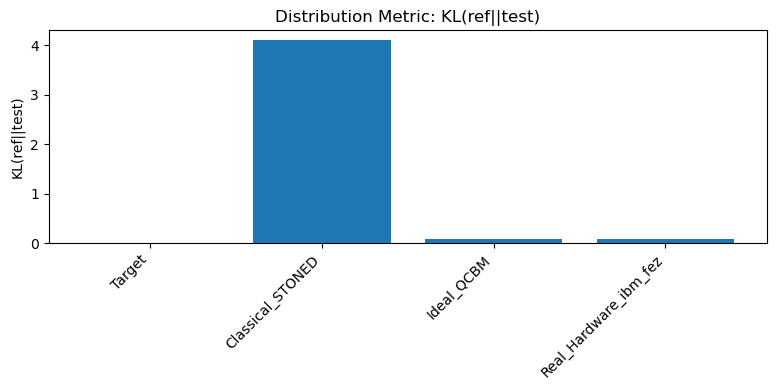

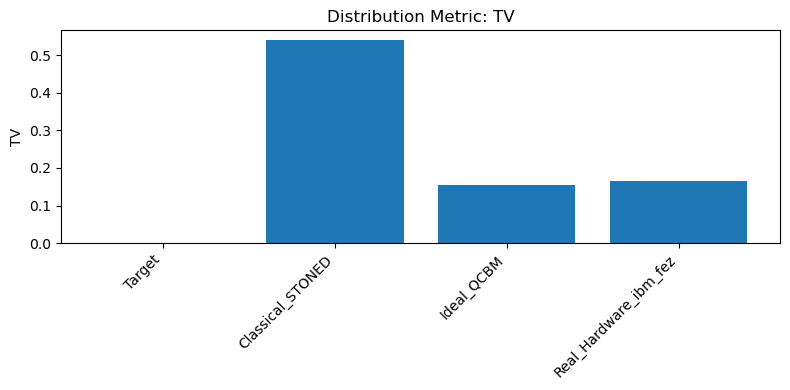

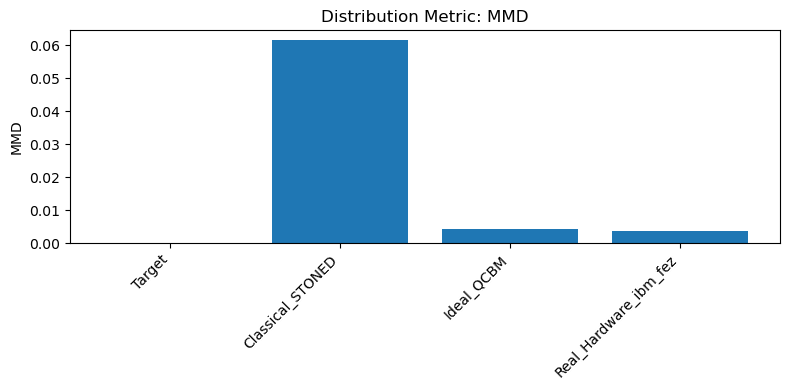

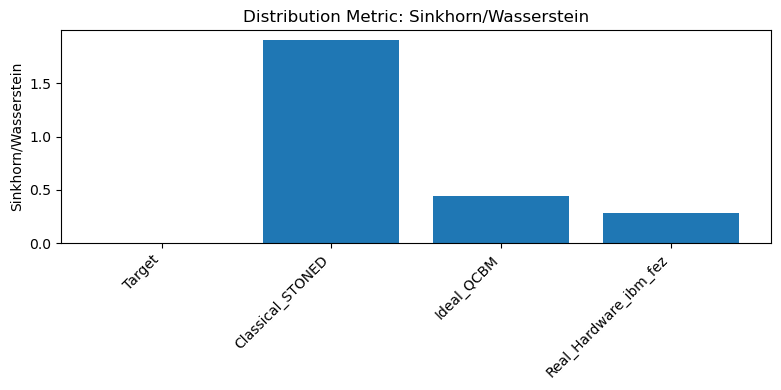

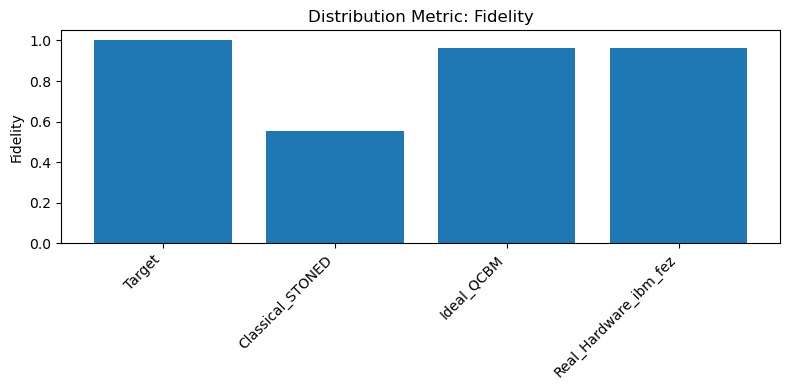

In [84]:
# ============================================================
# CELL 28 — Plot Distribution Metrics
# ============================================================

import matplotlib.pyplot as plt

distribution_plot_cols = [
    "KL(ref||test)",
    "TV",
    "MMD",
    "Sinkhorn/Wasserstein",
    "Fidelity"
]

for col in distribution_plot_cols:
    plt.figure(figsize=(8, 4))
    plt.bar(df_distribution_metrics["method"], df_distribution_metrics[col])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(col)
    plt.title(f"Distribution Metric: {col}")
    plt.tight_layout()
    plt.show()

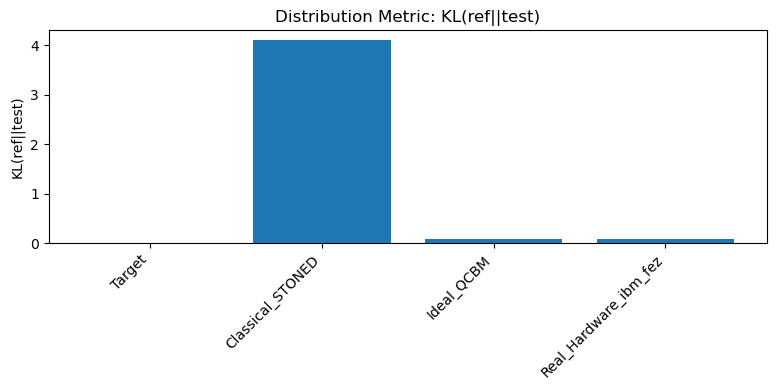

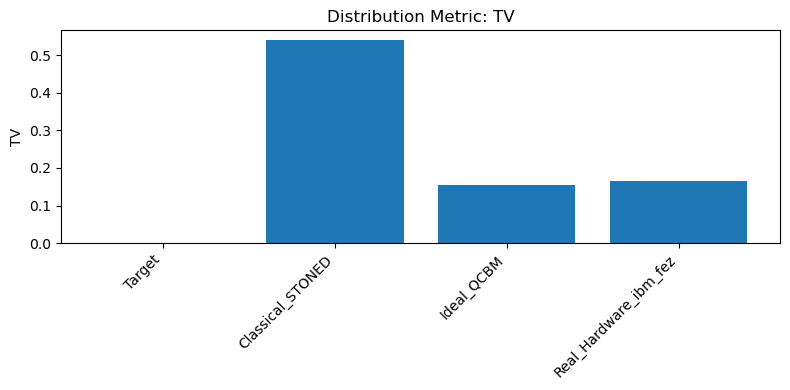

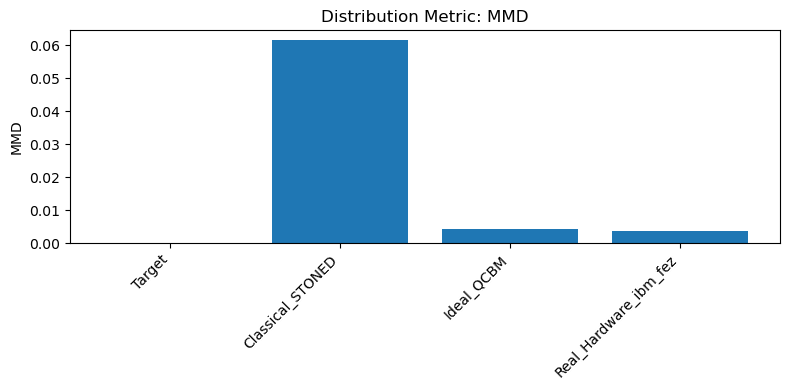

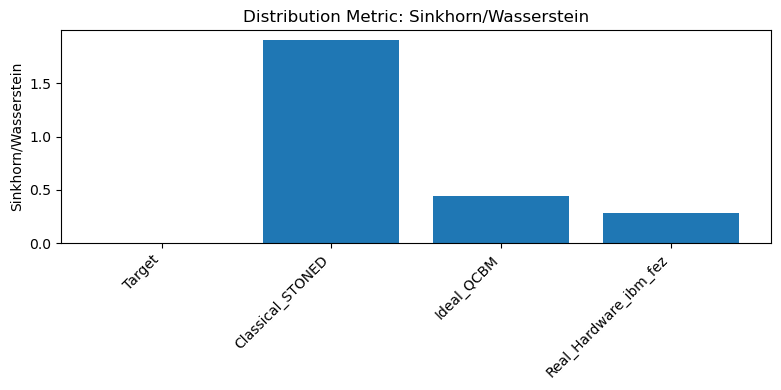

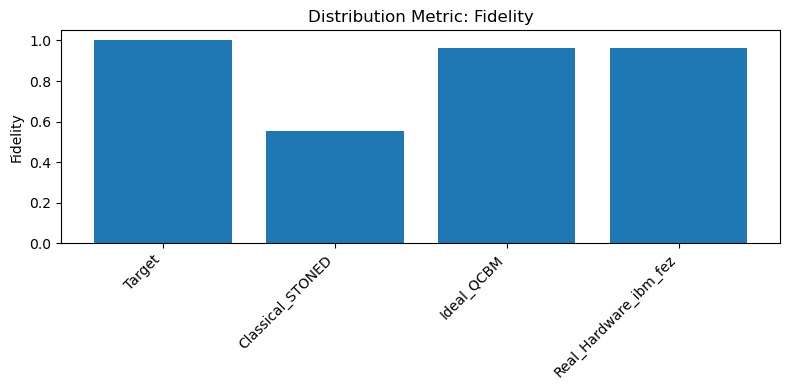

In [85]:
# ============================================================
# CELL 28 — Plot Distribution Metrics
# ============================================================

import matplotlib.pyplot as plt

distribution_plot_cols = [
    "KL(ref||test)",
    "TV",
    "MMD",
    "Sinkhorn/Wasserstein",
    "Fidelity"
]

for col in distribution_plot_cols:
    plt.figure(figsize=(8, 4))
    plt.bar(df_distribution_metrics["method"], df_distribution_metrics[col])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(col)
    plt.title(f"Distribution Metric: {col}")
    plt.tight_layout()
    plt.show()